# 02. フーリエ級数 — 周期関数を波の和で表す

**この章のゴール**: 周期関数を三角関数(または複素指数)の和で表す **フーリエ級数** を作り、
矩形波・のこぎり波・三角波で係数を計算し、不連続点に現れる **Gibbs 現象** を観察する。

## Big Picture

周期 $2\pi$ の関数 $f$ は、基本波とその倍音の重ね合わせで書けます。

$$ f(x) \sim \frac{a_0}{2} + \sum_{n=1}^{\infty}\bigl(a_n\cos nx + b_n\sin nx\bigr)
        = \sum_{n=-\infty}^{\infty} c_n e^{inx} $$

01 章の直交性のおかげで、各係数は内積一発で取り出せます。

## Problem

カクカクした **矩形波** を、滑らかな正弦波だけで表せるでしょうか。
直感的には無理そうですが、無限に倍音を足せば近づきます。何が起き、どこで破綻するかを見ます。

## Intuition — 基本波に倍音を足していく

矩形波(period $2\pi$)は奇関数なので、**奇数次の正弦波だけ**で作れます。

$$ \text{square}(x) = \frac{4}{\pi}\sum_{k=0}^{\infty}\frac{\sin\bigl((2k+1)x\bigr)}{2k+1} $$

倍音を足すほど角が立ち、矩形に近づきます。下の図とスライダーで確かめましょう。

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

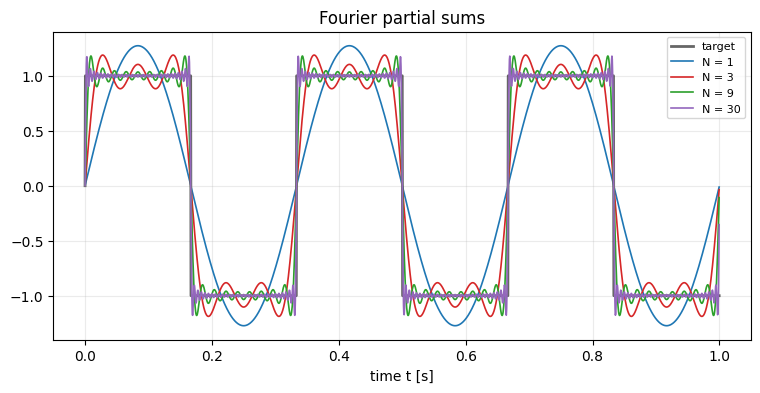

In [2]:
# Build a square wave from its odd harmonics; more terms -> sharper corners.
t, _ = signals.time_grid(1.0, 2000.0)
target = signals.square_wave(t, freq=3.0)
orders = [1, 3, 9, 30]
partials = [signals.square_wave_partial_sum(t, 3.0, k) for k in orders]
plotting.plot_partial_sums(t, partials, orders, target=target)
plt.show()

In [3]:
# Interactive (JupyterLab): slide the number of odd harmonics.
try:
    widgets.interactive_square_partial_sum()
except Exception as e:
    print("interactive demo needs JupyterLab:", e)

interactive(children=(IntSlider(value=1, description='n_terms', max=40, min=1), Output()), _dom_classes=('widg…

### 部分和の収束を一望(小分割)

倍音数 $N$ を増やすほど角が立ち、矩形波に近づく様子を並べて見る。

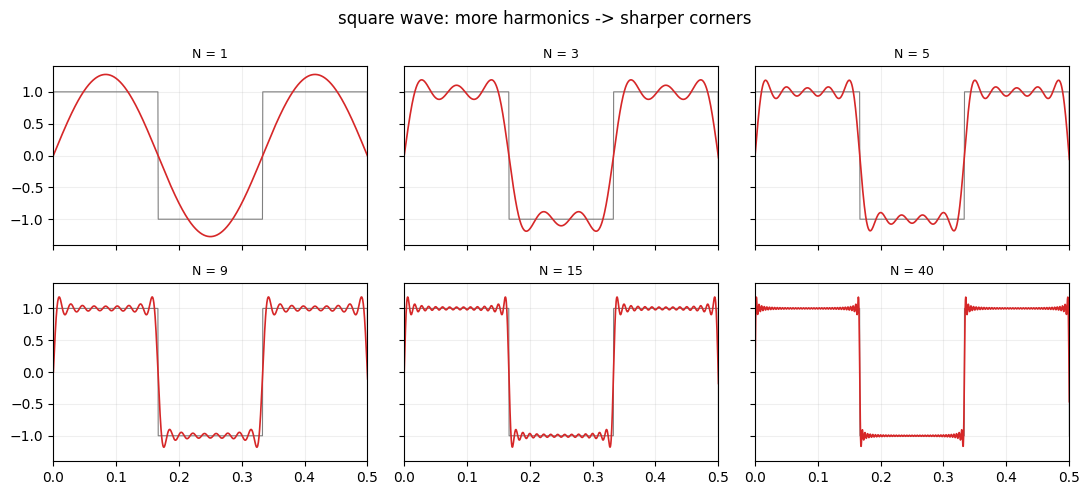

In [4]:
# Small multiples: the square wave emerges as more odd harmonics are added.
t, _ = signals.time_grid(1.0, 2000.0)
target = signals.square_wave(t, 3.0)
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True, sharey=True)
for ax, N in zip(axes.ravel(), [1, 3, 5, 9, 15, 40], strict=True):
    ax.plot(t, target, color="gray", lw=0.8)
    ax.plot(t, signals.square_wave_partial_sum(t, 3.0, N), color="#d62728", lw=1.2)
    ax.set_title(f"N = {N}", fontsize=9)
    ax.set_xlim(0, 0.5)
    ax.grid(alpha=0.2)
fig.suptitle("square wave: more harmonics -> sharper corners")
fig.tight_layout()
plt.show()

## Definition — 三角級数と複素級数

$$ a_n = \frac{1}{\pi}\int_{-\pi}^{\pi} f(x)\cos nx\,dx, \qquad
   b_n = \frac{1}{\pi}\int_{-\pi}^{\pi} f(x)\sin nx\,dx $$

複素形では

$$ c_n = \frac{1}{2\pi}\int_{-\pi}^{\pi} f(x)\,e^{-inx}\,dx, \qquad
   c_n = \tfrac{1}{2}(a_n - i b_n)\ (n>0). $$

**偶関数**なら $b_n=0$(余弦だけ)、**奇関数**なら $a_n=0$(正弦だけ)。
$a_0/2$ は平均値(DC 成分)です。

## Computation — 係数を数値で求める

`transforms.trig_coeffs` で矩形波の係数を計算します。奇数次の $b_n$ が
$\tfrac{4}{\pi n}$ に一致し、偶数次と $a_n$ がほぼ 0 になることを確認します。

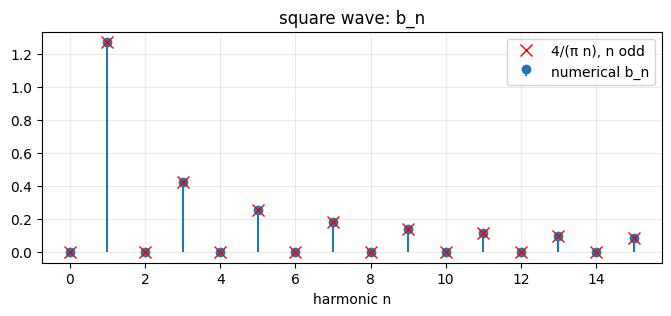

max |a_n| (should be ~0): 0.0004882812500002429


In [5]:
# Trig coefficients of a period-2π square wave: b_n = 4/(π n) for odd n, else 0.
square_2pi = lambda x: np.sign(np.sin(x))
a, b = transforms.trig_coeffs(square_2pi, n_max=15, period=2 * np.pi)
n = np.arange(len(b))
theory = np.where(n % 2 == 1, 4 / (np.pi * np.where(n == 0, 1, n)), 0.0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(n, b, basefmt=" ", linefmt="C0-", markerfmt="C0o", label="numerical b_n")
ax.plot(n, theory, "rx", ms=9, label="4/(π n), n odd")
ax.set_xlabel("harmonic n"); ax.set_title("square wave: b_n"); ax.legend(); ax.grid(alpha=0.25)
plt.show()
print("max |a_n| (should be ~0):", np.abs(a).max())

## Invariant / Energy — DC 成分と対称性

$a_0/2$ は 1 周期の平均。奇対称なら正弦のみ、偶対称なら余弦のみ、という対称性は
係数の半分をゼロにします。次に、矩形・のこぎり・三角の **係数の減衰の速さ** を比べます。
これが 03 章の「滑らかさ ↔ 係数減衰」に直結します。

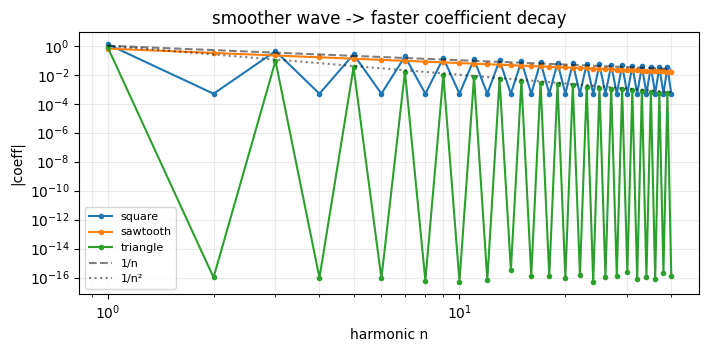

In [6]:
# Coefficient decay: square (~1/n), sawtooth (~1/n), triangle (~1/n^2).
period = 2 * np.pi
f_sq  = lambda x: signals.square_wave(x, 1 / period)
f_saw = lambda x: signals.sawtooth_wave(x, 1 / period)
f_tri = lambda x: signals.triangle_wave(x, 1 / period)

n_max = 40
ns = np.arange(1, n_max + 1)
mags = {}
for name, f in [("square", f_sq), ("sawtooth", f_saw), ("triangle", f_tri)]:
    a, b = transforms.trig_coeffs(f, n_max=n_max, period=period)
    mags[name] = np.hypot(a[1:], b[1:])

fig, ax = plt.subplots(figsize=(8, 3.4))
for name in mags:
    ax.loglog(ns, mags[name] + 1e-18, "o-", ms=3, label=name)
ax.loglog(ns, 1 / ns, "k--", alpha=.5, label="1/n")
ax.loglog(ns, 1 / ns**2, "k:", alpha=.5, label="1/n²")
ax.set_xlabel("harmonic n"); ax.set_ylabel("|coeff|"); ax.legend(fontsize=8)
ax.set_title("smoother wave -> faster coefficient decay"); ax.grid(alpha=.25, which="both")
plt.show()

## Failure Mode — Gibbs 現象

不連続点の近くでは、いくら倍音を足しても **約 9% の行き過ぎ(overshoot)** が残ります。
これは消えず、ジャンプの高さに対して一定比 $\approx 1.0895$(半ジャンプの約 18%)に収束します。
平均二乗では収束しても、各点・最大値では収束しないことの典型例です(03 章で再訪)。

peak of partial sum: 1.1789927655351262  (target is 1.0; ~1.0895 overshoot)


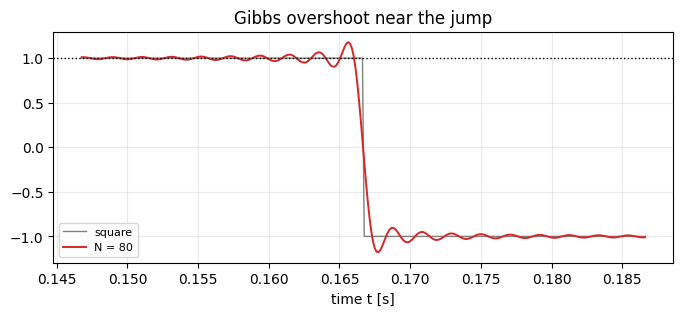

In [7]:
# Gibbs overshoot near a jump does not shrink with more terms.
t, _ = signals.time_grid(1.0, 8000.0)
approx = signals.square_wave_partial_sum(t, freq=3.0, n_terms=80)
print("peak of partial sum:", approx.max(), " (target is 1.0; ~1.0895 overshoot)")

jump = 1 / 6  # first jump of a 3 Hz square wave
sel = (t > jump - 0.02) & (t < jump + 0.02)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t[sel], signals.square_wave(t, 3.0)[sel], color="gray", lw=1, label="square")
ax.plot(t[sel], approx[sel], color="#d62728", lw=1.4, label="N = 80")
ax.axhline(1.0, color="black", ls=":", lw=1)
ax.set_title("Gibbs overshoot near the jump"); ax.set_xlabel("time t [s]")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.show()

## Application — 波形合成(音色)

倍音の振幅の配り方が **音色** を決めます。同じ基本周波数でも、矩形・のこぎり・三角は
倍音構成が違うので違う音に聞こえます。複素級数からの再構成も確認しておきます。

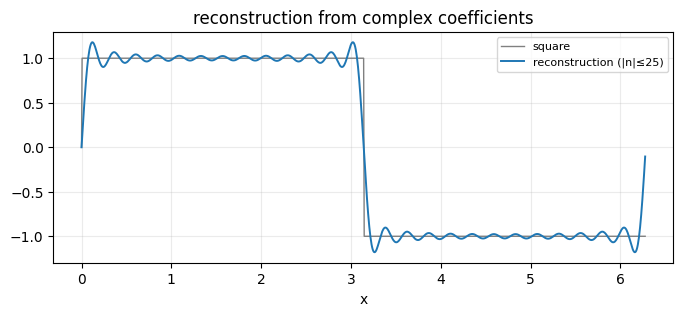

In [8]:
# Reconstruct the square wave from complex coefficients c_n.
ns, c = transforms.fourier_series_coeffs(square_2pi, n_max=25, period=2 * np.pi)
xx = np.linspace(0, 2 * np.pi, 1000, endpoint=False)
rec = transforms.reconstruct_complex(ns, c, xx, period=2 * np.pi)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(xx, square_2pi(xx), color="gray", lw=1, label="square")
ax.plot(xx, rec, color="#1f77b4", lw=1.4, label="reconstruction (|n|≤25)")
ax.set_title("reconstruction from complex coefficients"); ax.set_xlabel("x")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.show()

## Exercises

1. **のこぎり波**: $f(x)=x$($-\pi<x<\pi$)の $b_n=2(-1)^{n+1}/n$ を `trig_coeffs` で確認せよ。
2. **三角波の滑らかさ**: 三角波の係数が $1/n^2$ で減衰することを log-log 図で確かめ、
   矩形波($1/n$)との違いを説明せよ。
3. **偶奇分解**: 任意の関数を偶部 $\tfrac{1}{2}(f(x)+f(-x))$ と奇部に分け、
   前者が余弦のみ・後者が正弦のみで表せることを数値で示せ。
4. **Gibbs**: 倍音数 $N$ を変えても overshoot 比が一定に近づくことを表で示せ。

## Advanced Notes

```{admonition} Dirichlet の収束定理(要約)
:class: note
$f$ が区分的に滑らかなら、フーリエ級数は連続点で $f(x)$ に、跳びの点では
左右極限の平均 $\tfrac{1}{2}(f(x^+)+f(x^-))$ に **各点収束** する。Gibbs の overshoot は
この各点収束と矛盾しない — overshoot の位置がジャンプに限りなく近づくため。
```

- Gibbs の overshoot 比は $\frac{1}{\pi}\int_0^\pi \frac{\sin t}{t}dt \approx 1.0895$(半ジャンプ基準)。
- 緩和策: Fejér 平均(部分和の算術平均)や $\sigma$-近似(Lanczos)で overshoot を抑えられる。